<a href="https://colab.research.google.com/github/muajnstu/CAST/blob/main/Copy_of_Expectation_explainabilty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SHAP

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import textwrap

import shap

from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, StackingClassifier, BaggingClassifier, VotingClassifier
)
import matplotlib.cm as cm
import matplotlib.colors as mcolors



In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/muajnstu/CAST/refs/heads/main/Expectation/B1_RandomOverSampling%20%2B%20FS1_Correlation%20%20-%20Copy.csv")

In [ ]:
print('DataFrame columns:', df.columns)
X = df.drop(['CAST '], axis=1)
y = df['CAST ']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

DataFrame columns: Index(['Hotel Appeal', 'Staff Appearance', 'Service Consistency',
       'Commitment Reliability', 'Customer Responsiveness', 'Customer Info',
       'Invoice Accuracy', 'Cost Clarity', 'Problem Resolution',
       'Staff Availability', 'Tourist Responsiveness', 'Checkin Speed',
       'Guest Promptness', 'Staff Courtesy', 'Service Training',
       'Security Trust', 'Staff Knowledge', 'Safety Assurance', 'Local Info',
       'Prompt Delivery', 'Operating Hours', 'Active Listening',
       'Personal Care', 'Welcome Politeness', 'Mgt Acknowledgement',
       'Compensation Offer', 'Issue Reporting', 'Complaint Understanding',
       'Polite Handling', 'Price Equity', 'Budget Rate', 'Perceived Value',
       'Economic Fit', 'Facility Convenience', 'Physical Access',
       'Info Access', 'WiFi Reliability', 'Website Clarity',
       'Tourist Proximity', 'Walkable Access', 'Public Transport',
       'Location Suitability', 'CAST '],
      dtype='object')


In [ ]:
model = ExtraTreesClassifier(random_state=42)
model.fit(X_train, y_train)


X_train = X_train.drop(['CAST'], axis=1, errors='ignore')

explainer = shap.TreeExplainer(model)

X_test_shap = X_test.drop(['CAST'], axis=1, errors='ignore')
shap_values = explainer.shap_values(X_test_shap)

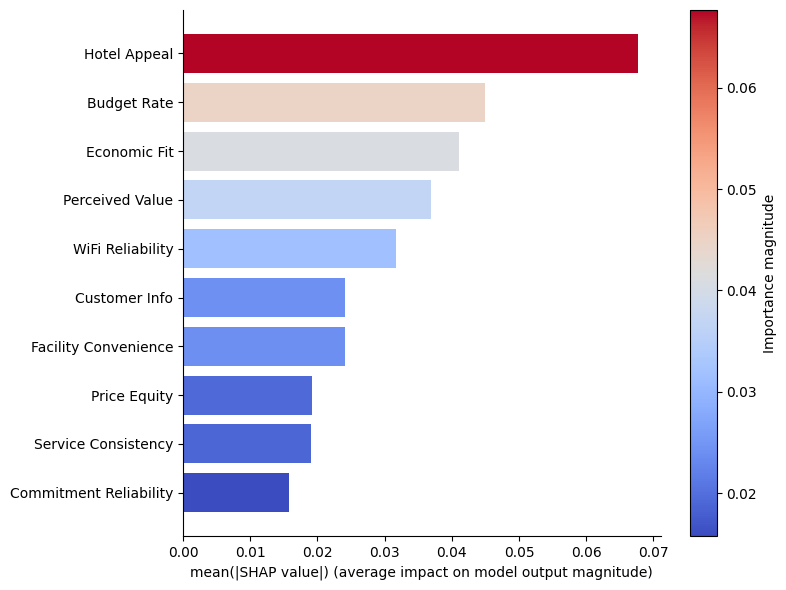

In [ ]:
shap_abs_mean = np.mean([np.abs(shap_values[:, :, i]) for i in range(shap_values.shape[2])], axis=0)
mean_shap = np.mean(shap_abs_mean, axis=0)
feature_names = X_test_shap.columns.tolist()

sorted_idx = np.argsort(mean_shap)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_values = mean_shap[sorted_idx]

# takes the last 10 elements (the largest values)
top_features = sorted_features[-10:]
top_values = sorted_values[-10:]

norm = mcolors.Normalize(vmin=top_values.min(), vmax=top_values.max())
colors = cm.coolwarm(norm(top_values))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_features, top_values, color=colors) # Uses sliced data
ax.set_xlabel('mean(|SHAP value|) (average impact on model output magnitude)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

sm = cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Importance magnitude')

plt.tight_layout()
plt.savefig('shap_clean_bar.png', dpi=150)
plt.show()

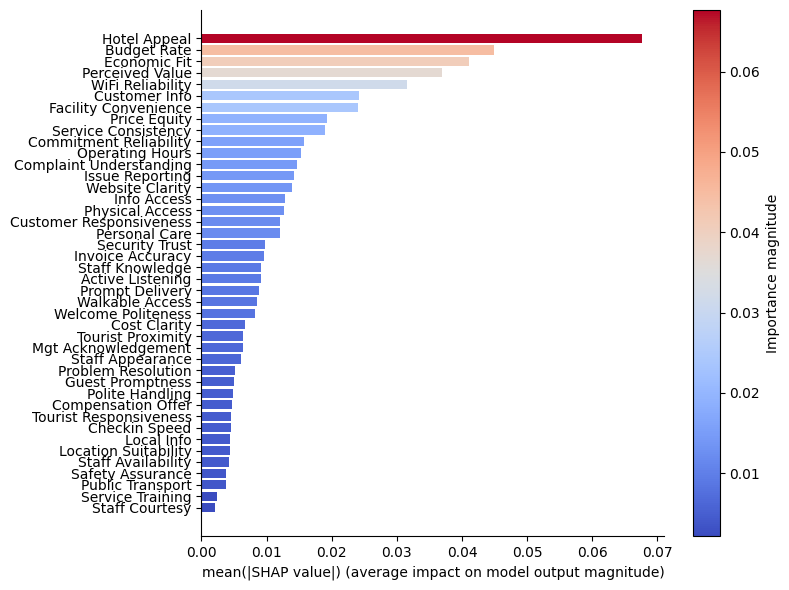

In [ ]:
shap_abs_mean = np.mean([np.abs(shap_values[:, :, i]) for i in range(shap_values.shape[2])], axis=0)

mean_shap = np.mean(shap_abs_mean, axis=0)
feature_names = X_test_shap.columns.tolist()

sorted_idx = np.argsort(mean_shap)
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_values = mean_shap[sorted_idx]

# Viridis gradient colors
norm = mcolors.Normalize(vmin=sorted_values.min(), vmax=sorted_values.max())
colors = cm.coolwarm(norm(sorted_values))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sorted_features, sorted_values, color=colors)
ax.set_xlabel('mean(|SHAP value|) (average impact on model output magnitude)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: add colorbar
sm = cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Importance magnitude')

plt.tight_layout()
plt.savefig('shap_clean_bar.png', dpi=150)
plt.show()

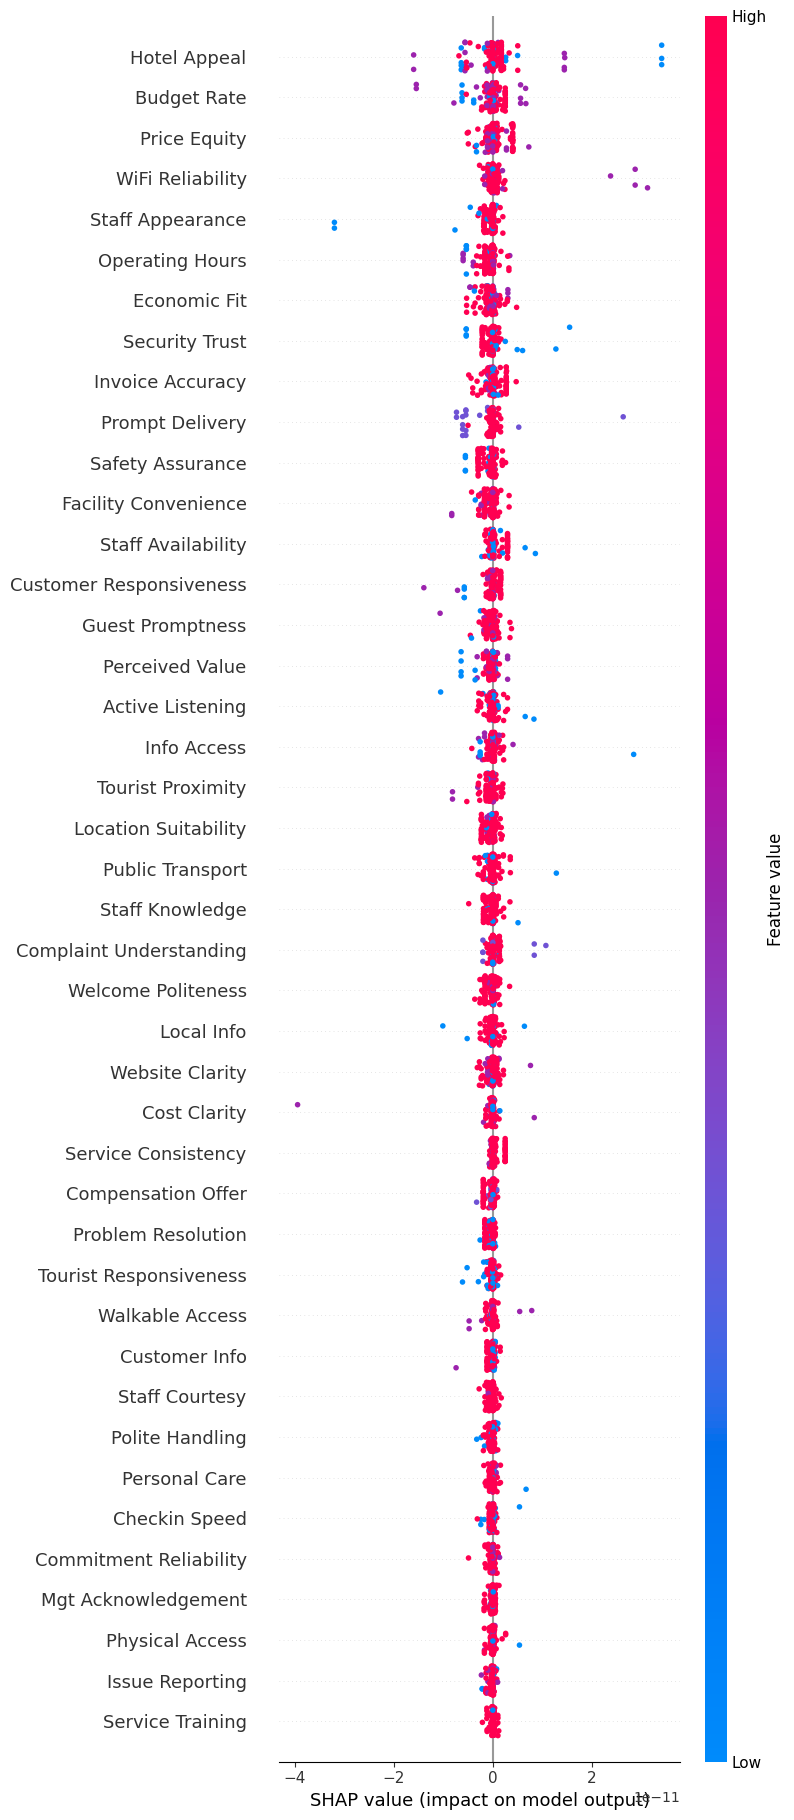

In [ ]:
shap_avg = np.mean(shap_values, axis=2)

explanation = shap.Explanation(
    values=shap_avg,
    data=X_test_shap.values,
    feature_names=X_test_shap.columns.tolist()
)

plt.figure()
shap.plots.beeswarm(
    explanation,
    max_display=len(X_test_shap.columns),  # show ALL features
    show=False
)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

LIME

In [ ]:
!pip install lime
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=22294be998879a8b3619f0046a4248a520394c352710cfabf3cdc475187c96f9
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
def predict_proba_func(x):

    if x.ndim == 1:
        x = x.reshape(1, -1)
    if x.shape[1] != X_train.shape[1]:
        print(f"Warning: Input shape mismatch. Expected {X_train.shape[1]} features, but got {x.shape[1]}.")
    x_df = pd.DataFrame(x, columns=X_train.columns)

    return model.predict_proba(x_df)

feature_names = X_train.columns.tolist()

class_names = [str(c) for c in np.unique(y_train)]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

sample_to_explain_index = 50
sample_to_explain = X_test.iloc[sample_to_explain_index].values


explanation = explainer.explain_instance(
    data_row=sample_to_explain,
    predict_fn=predict_proba_func,
    num_features=10,
    num_samples=5000
)

In [ ]:
explanation.show_in_notebook(show_table=True, show_all=False)

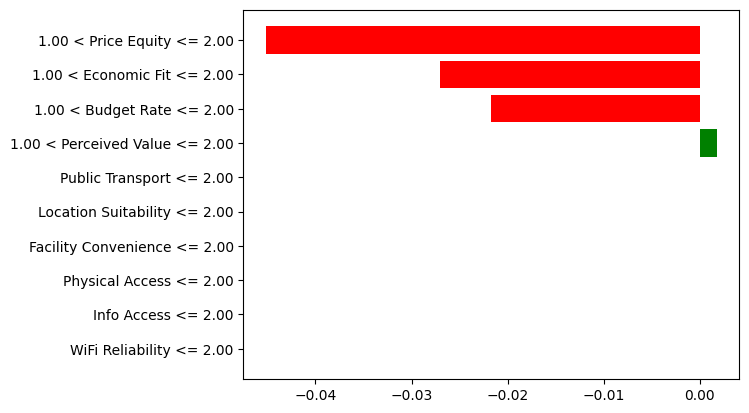

In [ ]:
fig = explanation.as_pyplot_figure()
fig.axes[0].set_title('')   # removes the title
fig.savefig('lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

PDP/ICE

In [ ]:
from sklearn.inspection import partial_dependence
from sklearn.inspection import PartialDependenceDisplay


In [ ]:
pdp_importance = []

for i, feature in enumerate(X.columns):
    pdp_results = partial_dependence(model, X_train, [i], kind='average')

    feature_range = np.ptp(pdp_results.average[0], axis=0)  # ptp = max-min

    importance_score = np.mean(feature_range)

    pdp_importance.append((feature, importance_score))

# Convert to DataFrame and sort
pdp_importance_df = pd.DataFrame(pdp_importance, columns=['Feature', 'PDP_Importance'])
pdp_importance_df = pdp_importance_df.sort_values(by='PDP_Importance', ascending=True)


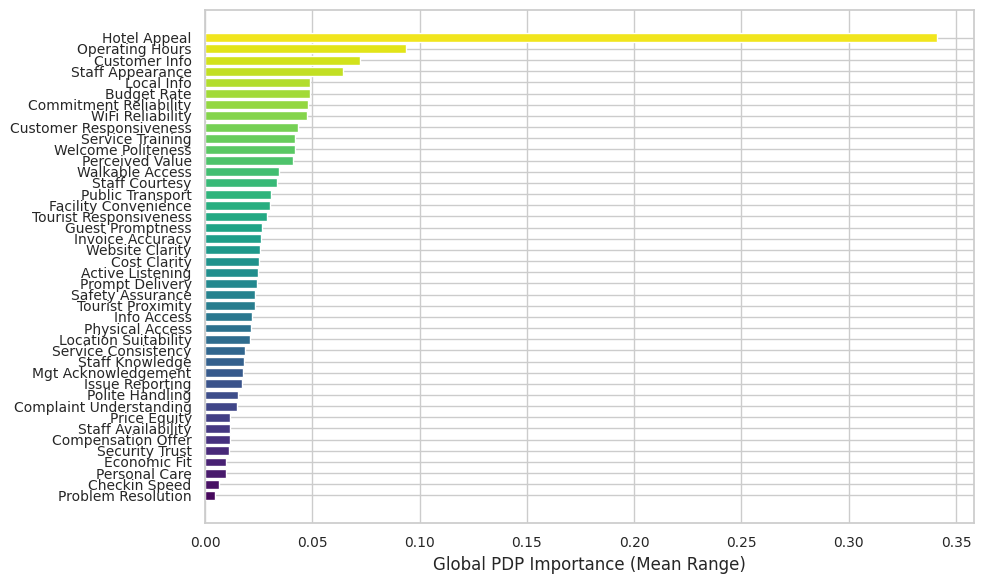

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
colors = sns.color_palette("viridis", len(pdp_importance_df))  # eye-catching gradient
plt.barh(pdp_importance_df['Feature'], pdp_importance_df['PDP_Importance'], color=colors)
plt.xlabel('Global PDP Importance (Mean Range)', fontsize=12)
plt.ylabel('')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.savefig("PDP_Global_Feature_Importance.png", dpi=300)
plt.show()


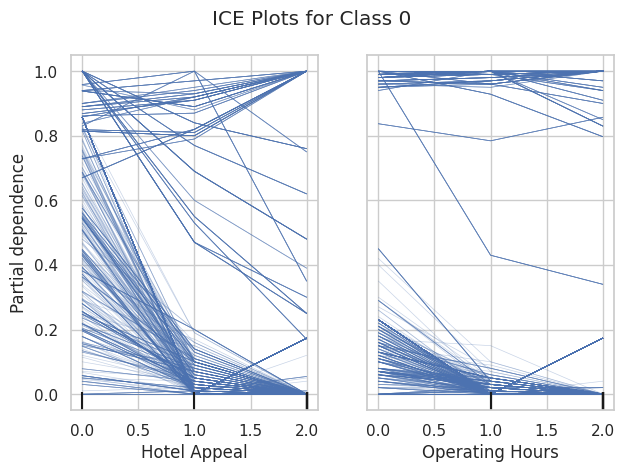

In [ ]:
features_to_plot = ['Hotel Appeal', 'Operating Hours']  # column names or indices
target_class = 0

display = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features_to_plot,
    target=target_class,
    kind='individual',
    grid_resolution=50,
)

plt.suptitle(f'ICE Plots for Class {target_class}')
plt.tight_layout()
plt.show()